In [1]:
graphics_toolkit('gnuplot')


The FLTK graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.
The qt toolkit is recommended instead.


The gnuplot graphics toolkit is not actively maintained and has a number
of limitations that are unlikely to be fixed.  Communication with gnuplot
uses a one-directional pipe and limited information is passed back to the
Octave interpreter so most changes made interactively in the plot window
will not be reflected in the graphics properties managed by Octave.  For
example, if the plot window is closed with a mouse click, Octave will not
be notified and will not update its internal list of open figure windows.
The qt toolkit is recommended instead.


In [2]:
format free

In [ ]:
a = 0;
b = 1;
h = 0.04; % 0.1
alpha = 0.03; % 0.04

N = round((b - a) / h) + 1;
s = linspace(a, b, N);

z_exact = s;

C = zeros(N, N);
B = zeros(N, N);
U = zeros(N, 1);

In [4]:
for i = 2 : N-1
    C(i, i-1) = -alpha / h^2;
    C(i, i)   = alpha * (1 + 2/h^2);
    C(i, i+1) = -alpha / h^2;
end

C(1, 1) = 1;
C(1, 2) = -1;

C(N, N-1) = -1;
C(N, N)   = 1;

disp('C:');
disp(C);

C:
 1 -1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 -18.75 37.53 -18.75 0 0 0 0 0 0 0 0 0 0
 0 0 

In [5]:
for i = 2 : N-1
    for j = 1 : N
        B(i, j) = h * exp(-(s(i) + s(j)));
    end
end
B(:, N) = 0;
B(1, :) = 0;
B(N, :) = 0;
 
disp('B:');
disp(B);

B:
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0.0384316 0.0369247 0.0354768 0.0340858 0.0327492 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0
 0.0369247 0.0354768 0.0340858 0.0327492 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0.0141382 0
 0.0354768 0.0340858 0.0327492 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0.0141382 0.0135838 0
 0.0340858 0.0327492 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.016591

In [6]:
U(1) = 0;
U(N) = 0;

for i = 2 : N-1
    sum_val = 0;
    for j = 1 : N
        sum_val = sum_val + h * exp(-(s(i) + s(j))) * z_exact(i);
    end
    U(i) = sum_val;
end

disp('U:');
disp(U);

U:
 0
 0.025348
 0.0487082
 0.0701975
 0.0899267
 0.108001
 0.124519
 0.139576
 0.153261
 0.165658
 0.176847
 0.186904
 0.195901
 0.203904
 0.210979
 0.217185
 0.222581
 0.227219
 0.231151
 0.234426
 0.237088
 0.239182
 0.240746
 0.24182
 0.24244
 0


In [7]:
M = C + B;

disp('B+C:');
disp(M);

B+C:
 1 -1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 -18.7116 37.5669 -18.7145 0.0340858 0.0327492 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0
 0.0369247 -18.7145 37.5641 -18.7173 0.0314651 0.0302313 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0.0141382 0
 0.0354768 0.0340858 -18.7173 37.5615 -18.7198 0.029046 0.0279071 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0.0153157 0.0147152 0.0141382 0.0135838 0
 0.0340858 0.0327492 0.0314651 -18.7198 37.559 -18.7221 0.0268128 0.0257615 0.0247513 0.0237808 0.0228484 0.0219525 0.0210917 0.0202647 0.0194701 0.0187067 0.0179732 0.0172684 0.0165913 0.0159408 0

In [8]:
z = M \ U;

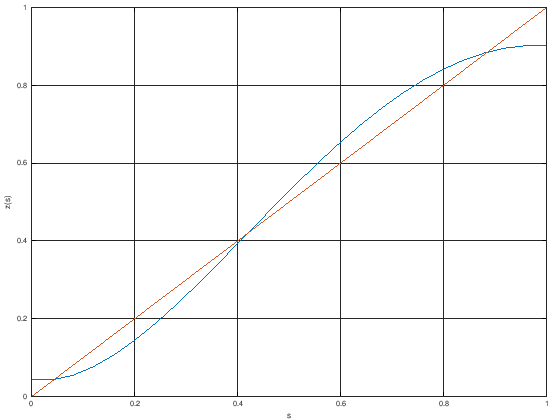

In [9]:
plot(s, z); 
hold on;
plot(s, z_exact);
grid on;
xlabel('s');
ylabel('z(s)');
hold off;